In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc


In [3]:
df = pd.read_csv("2015.csv")  
df.head()
df

,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENUM,...,_PAREC1,_PASTAE1,_LMTACT1,_LMTWRK1,_LMTSCL1,_RFSEAT2,_RFSEAT3,_FLSHOT6,_PNEUMO2,_AIDTST3
0,1.0,1.0,b'01292015',b'01',b'29',b'2015',1200.0,2.015000e+09,2.015000e+09,1.0,...,4.0,2.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,1.0
1,1.0,1.0,b'01202015',b'01',b'20',b'2015',1100.0,2.015000e+09,2.015000e+09,1.0,...,2.0,2.0,3.0,3.0,4.0,2.0,2.0,NaN,NaN,2.0
2,1.0,1.0,b'02012015',b'02',b'01',b'2015',1200.0,2.015000e+09,2.015000e+09,1.0,...,9.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0,NaN
3,1.0,1.0,b'01142015',b'01',b'14',b'2015',1100.0,2.015000e+09,2.015000e+09,1.0,...,4.0,2.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,9.0
4,1.0,1.0,b'01142015',b'01',b'14',b'2015',1100.0,2.015000e+09,2.015000e+09,1.0,...,4.0,2.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441451,72.0,11.0,b'12162015',b'12',b'16',b'2015',1100.0,2.015005e+09,2.015005e+09,NaN,...,4.0,2.0,2.0,2.0,3.0,1.0,1.0,2.0,2.0,2.0
441452,72.0,11.0,b'12142015',b'12',b'14',b'2015',1100.0,2.015005e+09,2.015005e+09,NaN,...,2.0,2.0,3.0,3.0,4.0,1.0,1.0,NaN,NaN,1.0
441453,72.0,11.0,b'12232015',b'12',b'23',b'2015',1200.0,2.015005e+09,2.015005e+09,NaN,...,9.0,9.0,3.0,3.0,4.0,9.0,9.0,9.0,9.0,NaN
441454,72.0,11.0,b'12152015',b'12',b'15',b'2015',1100.0,2.015005e+09,2.015005e+09,NaN,...,4.0,2.0,3.0,3.0,4.0,1.0,1.0,NaN,NaN,2.0


In [3]:
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 441456 entries, 0 to 441455
Columns: 330 entries, _STATE to _AIDTST3
dtypes: float64(323), object(7)
memory usage: 1.1+ GB


In [4]:
df.isnull().sum()


_STATE           0
FMONTH           0
IDATE            0
IMONTH           0
IDAY             0
             ...  
_RFSEAT2         0
_RFSEAT3         0
_FLSHOT6    283502
_PNEUMO2    283502
_AIDTST3     43387
Length: 330, dtype: int64

In [5]:
df.drop_duplicates(inplace=True)

print("After removing duplicates:", df.shape)


After removing duplicates: (441456, 330)


Cleaning Target Column

In [6]:
df = df[df["_MICHD"] <= 2].copy()


Creating Target Variable

In [7]:
df["HeartDisease"] = (df["_MICHD"] == 1).astype(int)


Dropping Old Column

In [8]:
df.drop("_MICHD", axis=1, inplace=True)


Define Features & Target

In [9]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]
#X = features
# y = target

In [10]:
# Drop columns with all NaN values
X = X.dropna(axis=1, how='all')

print("Shape after dropping empty columns:", X.shape)


Shape after dropping empty columns: (437514, 325)


In [ ]:
# Remove fully empty columns
X = X.dropna(axis=1, how='all')

# Fill missing values
X = X.fillna(X.mean())

print("Missing values:", X.isnull().sum().sum())


In [ ]:
df.isnull().sum()


In [26]:
X = X.select_dtypes(include=['int64', 'float64'])

print("Shape after numeric selection:", X.shape)


Shape after numeric selection: (437514, 322)


handling missing values

In [30]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

# Store values first
X_values = imputer.fit_transform(X)

# Convert back to DataFrame
X = pd.DataFrame(X_values, columns=X.columns)

print("Missing values after imputation:", X.isnull().sum().sum())


Missing values after imputation: 0


feature selection

In [31]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(score_func=chi2, k=15)
X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Top Features:")
print(selected_features)


Top Features:
Index(['WEIGHT2', 'HEIGHT3', 'ALCDAY5', 'STRENGTH', 'FLSHTMY2', 'HIVTSTD3',
       '_STSTR', '_LLCPWT', 'WTKG3', '_DRNKWEK', 'MAXVO2_', 'FC60_',
       'STRFREQ_', 'PAVIG11_', 'PA1VIGM_'],
      dtype='object')


correlation heatmap

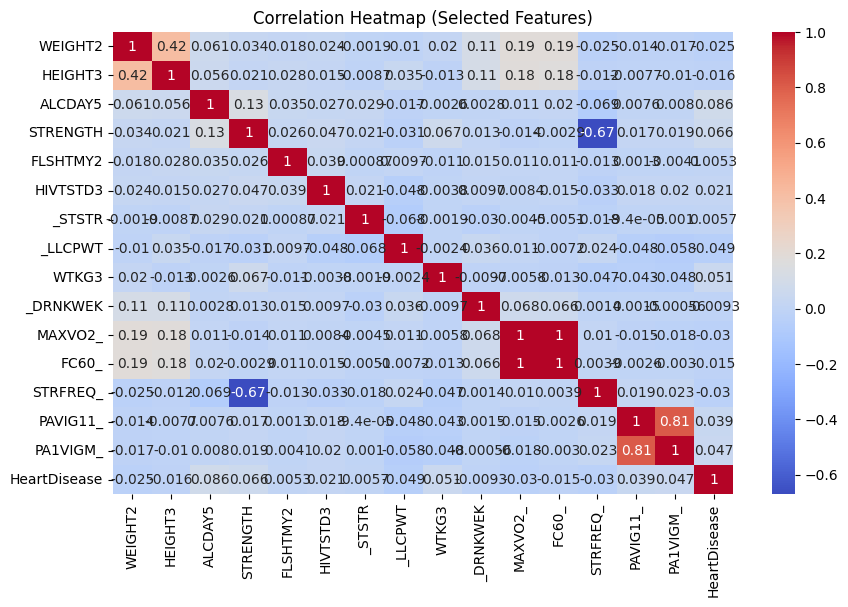

In [32]:
# Convert selected features into DataFrame
X_selected_df = pd.DataFrame(X_selected, columns=selected_features)

# Add target column
X_selected_df["HeartDisease"] = y.values

# Correlation
corr = X_selected_df.corr()

# Plot
plt.figure(figsize=(10, 6))

sns.heatmap(corr, 
            annot=True, 
            cmap='coolwarm')

plt.title("Correlation Heatmap (Selected Features)")
plt.show()


train test split

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)


feature scaling

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Logistic Regression

In [35]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)


knn

In [36]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)


svm

In [ ]:
from sklearn.svm import SVC

svm = SVC(kernel='linear', probability=True)
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)
